In [ ]:
#1
#new code

!pip uninstall -y transformers
!pip install -q transformers==4.55.4 datasets==4.0.0 accelerate==1.10.1 evaluate sentencepiece scikit-learn

Found existing installation: transformers 5.14.1
Uninstalling transformers-5.14.1:
  Successfully uninstalled transformers-5.14.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 81.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.8/494.8 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.9/374.9 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 90.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [ ]:
#2
import pandas as pd
import numpy as np
import torch

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [ ]:
#3
from google.colab import files

uploaded = files.upload()

Saving amharic_speech_acts_test.csv to amharic_speech_acts_test (1).csv
Saving amharic_speech_acts_train.csv to amharic_speech_acts_train (1).csv
Saving amharic_speech_acts_val.csv to amharic_speech_acts_val (1).csv


In [ ]:
#4
train_df = pd.read_csv("amharic_speech_acts_train.csv")
valid_df = pd.read_csv("amharic_speech_acts_val.csv")
test_df = pd.read_csv("amharic_speech_acts_test.csv")

print(train_df.head())

   id                                           text      label  label_id
0   1             ስጦታው ገና ወደ አውሮፕላን ማረፊያ ነገ አልደረሰኝም።  Complaint         6
1   2                  እባክዎ ውሉን ለደንበኛው በዚህ ወር ይላኩልኝ።    Request         0
2   4                 እባክዎ ትዕዛዙን ለፖሊሱ በዚህ አመት ይላኩልኝ።    Request         0
3   6             የትዕዛዙ ችግር ከምሽቱ ጀምሮ ከጓደኛዬ ጋር እፈታለሁ።    Promise         8
4   9  ደብዳቤው ገና ወደ አውሮፕላን ማረፊያ ከአንድ ሰዓት በኋላ አልደረሰኝም።  Complaint         6


In [ ]:
#5
train_df = train_df[["text","label_id"]]
valid_df = valid_df[["text","label_id"]]
test_df = test_df[["text","label_id"]]


train_df = train_df.rename(columns={"label_id":"labels"})
valid_df = valid_df.rename(columns={"label_id":"labels"})
test_df = test_df.rename(columns={"label_id":"labels"})

In [ ]:
#6
id2label = {
    0:"Request",
    1:"Assertion",
    2:"Refusal",
    3:"Suggestion",
    4:"Warning",
    5:"Sarcasm",
    6:"Complaint",
    7:"Phatic",
    8:"Promise",
    9:"Question"
}

label2id = {v:k for k,v in id2label.items()}

In [ ]:
#7
train_dataset = Dataset.from_pandas(train_df)
valid_dataset = Dataset.from_pandas(valid_df)
test_dataset = Dataset.from_pandas(test_df)

In [ ]:
#8
MODEL_NAME = "Davlan/afro-xlmr-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [ ]:
#9
def tokenize(batch):

    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128
    )


train_dataset = train_dataset.map(tokenize, batched=True)
valid_dataset = valid_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/7955 [00:00<?, ? examples/s]

Map:   0%|          | 0/1857 [00:00<?, ? examples/s]

Map:   0%|          | 0/1663 [00:00<?, ? examples/s]

In [ ]:
#10
data_collator = DataCollatorWithPadding(tokenizer)

train_dataset=train_dataset.remove_columns(["text"])
valid_dataset=valid_dataset.remove_columns(["text"])
test_dataset=test_dataset.remove_columns(["text"])

train_dataset.set_format("torch")
valid_dataset.set_format("torch")
test_dataset.set_format("torch")
test_dataset.set_format("torch")

ValueError: Column name ['text'] not in the dataset. Current columns in the dataset: ['labels', 'input_ids', 'attention_mask']

In [ ]:
#11
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=10,
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: Davlan/afro-xlmr-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
#12
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy":accuracy,
        "precision":precision,
        "recall":recall,
        "f1":f1
    }

In [ ]:
#13
training_args = TrainingArguments(

    output_dir="./AfroXLMR",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=10,

    weight_decay=0.01,

    eval_strategy="epoch",

    save_strategy="epoch",

    logging_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    greater_is_better=True,

    save_total_limit=2,

    fp16=torch.cuda.is_available(),

    report_to="none",

    seed=42
)

In [ ]:
#14
training_args = TrainingArguments(

    output_dir="./AfroXLMR",

    eval_strategy="epoch",

    save_strategy="epoch",

    logging_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=10,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    greater_is_better=True,

    save_total_limit=2,

    fp16=True,

    report_to="none",

    seed=42
)

In [ ]:
#15
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=valid_dataset,

    processing_class=tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)

In [ ]:
#16
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.231479,0.816602,0.772213,0.686654,0.772213,0.715344
2,0.002008,0.937477,0.777060,0.695830,0.777060,0.721771
3,0.000904,1.088898,0.771136,0.678378,0.771136,0.710962
4,0.000552,1.102044,0.765213,0.710382,0.765213,0.722959
5,0.000377,1.215262,0.758751,0.699869,0.758751,0.713458
6,0.001443,1.244819,0.759828,0.699305,0.759828,0.714278
7,0.000220,1.284782,0.758751,0.698882,0.758751,0.713069
8,0.000182,1.341752,0.759828,0.701054,0.759828,0.714421
9,0.000159,1.354650,0.757674,0.696591,0.757674,0.711041
10,0.000149,1.277094,0.758212,0.695910,0.758212,0.710815


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4980, training_loss=0.02374744801576358, metrics={'train_runtime': 1428.7883, 'train_samples_per_second': 55.677, 'train_steps_per_second': 3.485, 'total_flos': 980536301240328.0, 'train_loss': 0.02374744801576358, 'epoch': 10.0})

In [ ]:
#17
results = trainer.evaluate(test_dataset)

print(results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.000149,1.254903,10,0.807577,0.854229,0.807577,0.789814


{'eval_loss': 1.2549030780792236, 'eval_accuracy': 0.8075766686710764, 'eval_precision': 0.8542288956062778, 'eval_recall': 0.8075766686710764, 'eval_f1': 0.7898143295713518}


In [ ]:
#18
trainer.save_model("AfroXLMR_Amharic_Intent")

tokenizer.save_pretrained(
    "AfroXLMR_Amharic_Intent"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('AfroXLMR_Amharic_Intent/tokenizer_config.json',
 'AfroXLMR_Amharic_Intent/tokenizer.json')

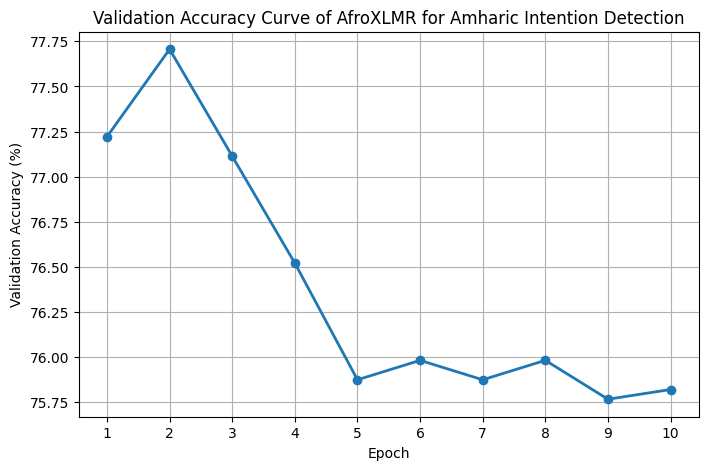

In [ ]:
import matplotlib.pyplot as plt

# Training results
epochs = [1,2,3,4,5,6,7,8,9,10]

accuracy = [
    0.772213,
    0.777060,
    0.771136,
    0.765213,
    0.758751,
    0.759828,
    0.758751,
    0.759828,
    0.757674,
    0.758212
]

# Convert to percentage
accuracy_percentage = [x*100 for x in accuracy]


plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    accuracy_percentage,
    marker='o',
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")

plt.title(
    "Validation Accuracy Curve of AfroXLMR for Amharic Intention Detection"
)

plt.xticks(epochs)

plt.grid(True)

plt.show()

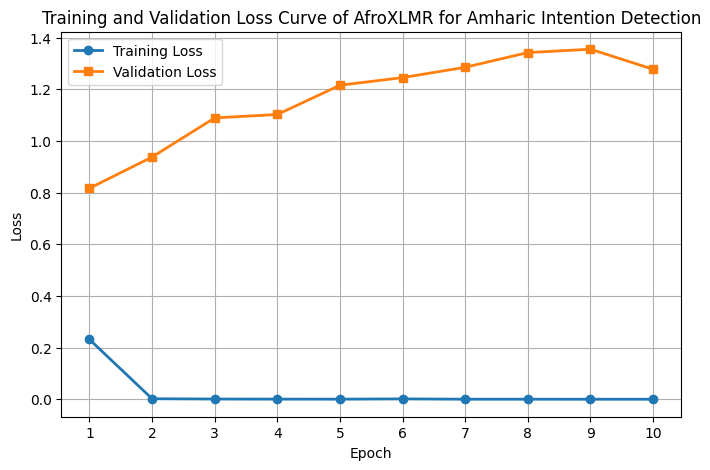

In [ ]:
import matplotlib.pyplot as plt

# Epoch numbers
epochs = [1,2,3,4,5,6,7,8,9,10]

# Loss values from your training result
training_loss = [
    0.231479,
    0.002008,
    0.000904,
    0.000552,
    0.000377,
    0.001443,
    0.000220,
    0.000182,
    0.000159,
    0.000149
]

validation_loss = [
    0.816602,
    0.937477,
    1.088898,
    1.102044,
    1.215262,
    1.244819,
    1.284782,
    1.341752,
    1.354650,
    1.277094
]


plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    training_loss,
    marker='o',
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    epochs,
    validation_loss,
    marker='s',
    linewidth=2,
    label="Validation Loss"
)


plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training and Validation Loss Curve of AfroXLMR for Amharic Intention Detection"
)

plt.xticks(epochs)

plt.legend()

plt.grid(True)

plt.show()

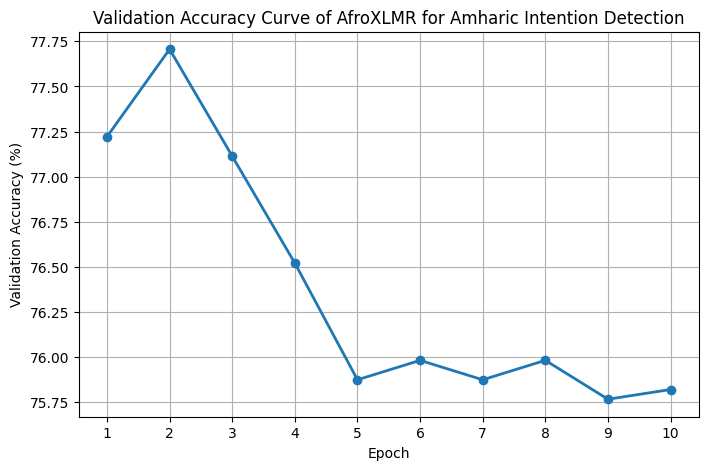

In [ ]:
import matplotlib.pyplot as plt

# Epoch values
epochs = [1,2,3,4,5,6,7,8,9,10]

# Validation accuracy values
accuracy = [
    0.772213,
    0.777060,
    0.771136,
    0.765213,
    0.758751,
    0.759828,
    0.758751,
    0.759828,
    0.757674,
    0.758212
]

# Convert accuracy to percentage
accuracy_percent = [x * 100 for x in accuracy]


plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    accuracy_percent,
    marker='o',
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")

plt.title(
    "Validation Accuracy Curve of AfroXLMR for Amharic Intention Detection"
)

plt.xticks(epochs)

plt.grid(True)

plt.show()

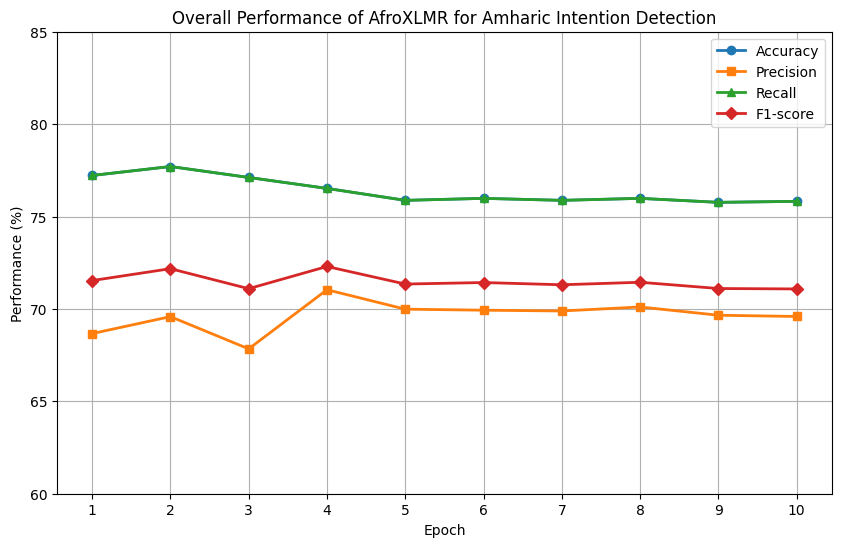

In [ ]:
import matplotlib.pyplot as plt

# Epochs
epochs = [1,2,3,4,5,6,7,8,9,10]

# Metrics from your training results
accuracy = [
    0.772213,
    0.777060,
    0.771136,
    0.765213,
    0.758751,
    0.759828,
    0.758751,
    0.759828,
    0.757674,
    0.758212
]

precision = [
    0.686654,
    0.695830,
    0.678378,
    0.710382,
    0.699869,
    0.699305,
    0.698882,
    0.701054,
    0.696591,
    0.695910
]

recall = [
    0.772213,
    0.777060,
    0.771136,
    0.765213,
    0.758751,
    0.759828,
    0.758751,
    0.759828,
    0.757674,
    0.758212
]

f1 = [
    0.715344,
    0.721771,
    0.710962,
    0.722959,
    0.713458,
    0.714278,
    0.713069,
    0.714421,
    0.711041,
    0.710815
]


# Convert to percentage
accuracy = [x*100 for x in accuracy]
precision = [x*100 for x in precision]
recall = [x*100 for x in recall]
f1 = [x*100 for x in f1]


plt.figure(figsize=(10,6))


plt.plot(epochs, accuracy,
         marker='o',
         linewidth=2,
         label="Accuracy")

plt.plot(epochs, precision,
         marker='s',
         linewidth=2,
         label="Precision")

plt.plot(epochs, recall,
         marker='^',
         linewidth=2,
         label="Recall")

plt.plot(epochs, f1,
         marker='D',
         linewidth=2,
         label="F1-score")


plt.xlabel("Epoch")
plt.ylabel("Performance (%)")

plt.title(
    "Overall Performance of AfroXLMR for Amharic Intention Detection"
)

plt.xticks(epochs)

plt.ylim(60,85)

plt.legend()

plt.grid(True)

plt.show()

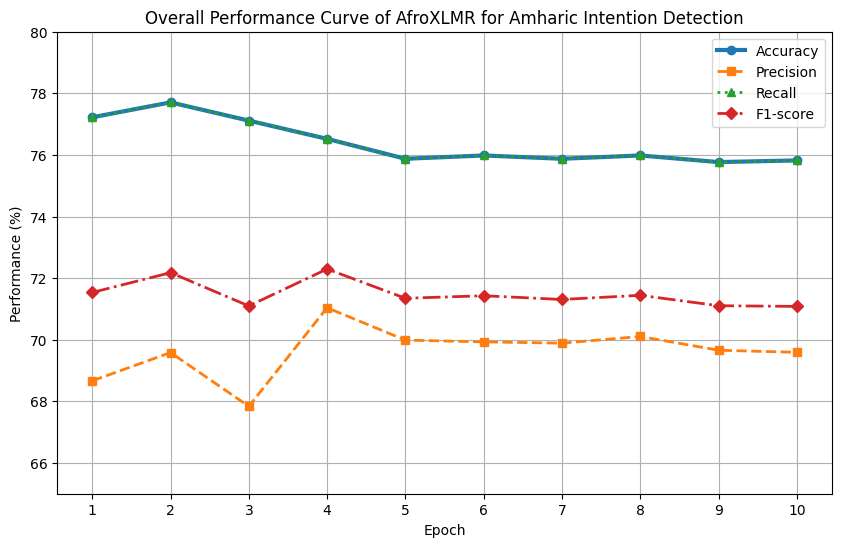

In [ ]:
import matplotlib.pyplot as plt

epochs = [1,2,3,4,5,6,7,8,9,10]

accuracy = [
    77.2213,
    77.7060,
    77.1136,
    76.5213,
    75.8751,
    75.9828,
    75.8751,
    75.9828,
    75.7674,
    75.8212
]

precision = [
    68.6654,
    69.5830,
    67.8378,
    71.0382,
    69.9869,
    69.9305,
    69.8882,
    70.1054,
    69.6591,
    69.5910
]

f1 = [
    71.5344,
    72.1771,
    71.0962,
    72.2959,
    71.3458,
    71.4278,
    71.3069,
    71.4421,
    71.1041,
    71.0815
]

recall = accuracy.copy()


plt.figure(figsize=(10,6))


# Plot Accuracy last so it is visible
plt.plot(
    epochs,
    accuracy,
    marker='o',
    linewidth=3,
    linestyle='-',
    label="Accuracy"
)

plt.plot(
    epochs,
    precision,
    marker='s',
    linewidth=2,
    linestyle='--',
    label="Precision"
)

plt.plot(
    epochs,
    recall,
    marker='^',
    linewidth=2,
    linestyle=':',
    label="Recall"
)

plt.plot(
    epochs,
    f1,
    marker='D',
    linewidth=2,
    linestyle='-.',
    label="F1-score"
)


plt.xlabel("Epoch")
plt.ylabel("Performance (%)")

plt.title(
    "Overall Performance Curve of AfroXLMR for Amharic Intention Detection"
)

plt.xticks(epochs)

plt.ylim(65,80)

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.metrics import confusion_matrix

In [ ]:
#2
# Predict on test dataset
prediction_output = trainer.predict(test_dataset)

# Get predicted class IDs
y_pred = np.argmax(
    prediction_output.predictions,
    axis=1
)

# Get true labels
y_true = prediction_output.label_ids

In [ ]:
#3
cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[122   0   0  51   0   0   0   0   0]
 [  0 176   0   0  13   1   0   0   0]
 [  0   0 244   0   0   0   0   0   0]
 [  0   0   0 185   0   0   0   0   0]
 [  0   0   0 101 104   0   0   0   0]
 [  0   0   0   0   1 185   0   0   0]
 [  0  32  23   0   7  38  53  37   0]
 [  0   0   0   0   0   0   0 171   0]
 [  0  16   0   0   0   0   0   0 103]]


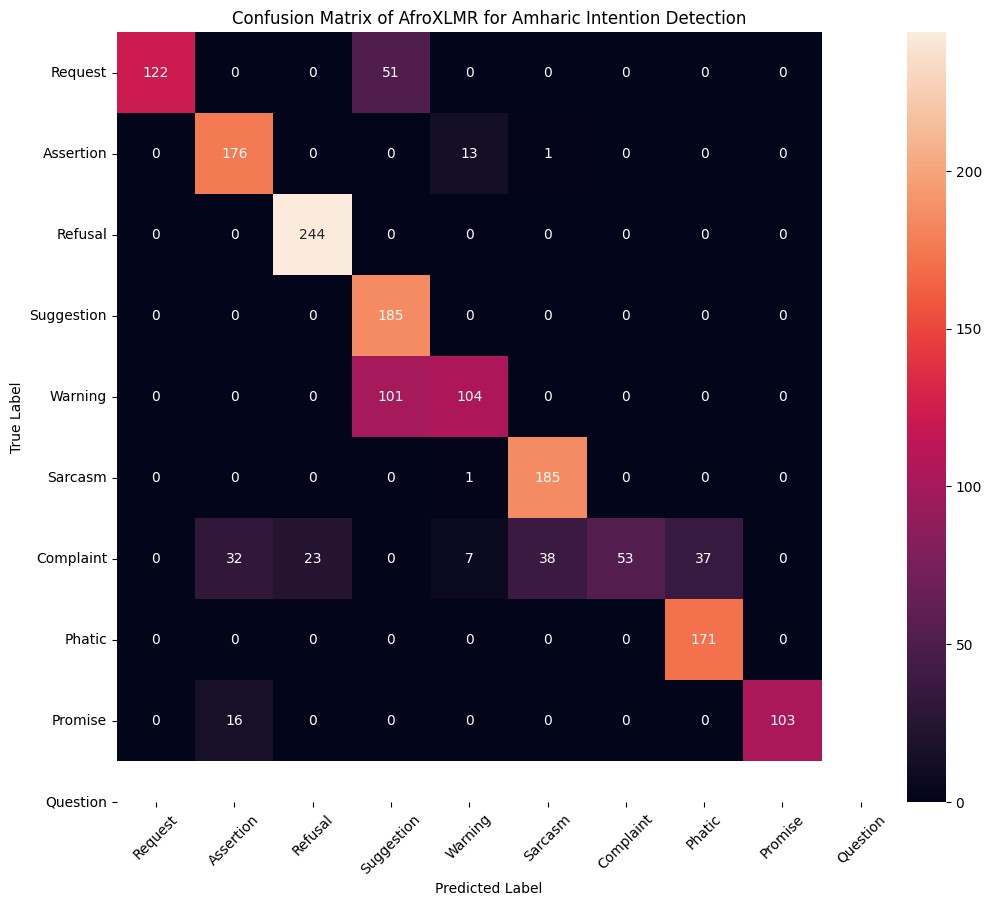

In [ ]:
#4
labels = [
    "Request",
    "Assertion",
    "Refusal",
    "Suggestion",
    "Warning",
    "Sarcasm",
    "Complaint",
    "Phatic",
    "Promise",
    "Question"
]


plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title(
    "Confusion Matrix of AfroXLMR for Amharic Intention Detection"
)

plt.xticks(rotation=45)

plt.yticks(rotation=0)

plt.show()

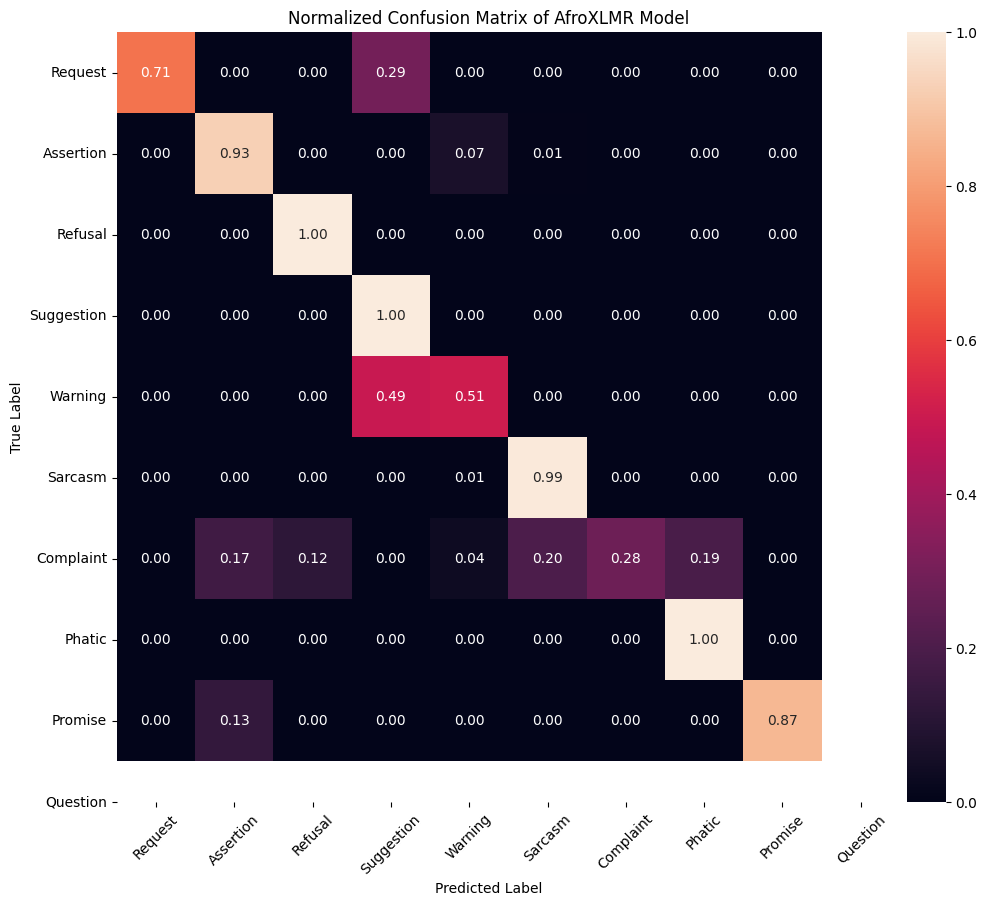

In [ ]:
#5
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


plt.figure(figsize=(12,10))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title(
    "Normalized Confusion Matrix of AfroXLMR Model"
)

plt.xticks(rotation=45)

plt.yticks(rotation=0)

plt.show()

In [ ]:
import numpy as np

print("True labels:", np.unique(y_true))
print("Predicted labels:", np.unique(y_pred))

True labels: [0 1 2 3 4 5 6 7 8]
Predicted labels: [0 1 2 3 4 5 6 7 8]


In [ ]:
print(train_df["labels"].value_counts().sort_index())
print(valid_df["labels"].value_counts().sort_index())
print(test_df["labels"].value_counts().sort_index())

labels
0    929
1    897
2    867
3    891
4    889
5    896
6    895
7    873
8    818
Name: count, dtype: int64
labels
0    173
1    188
2    164
3    199
4    181
5    193
6    190
7    231
8    338
Name: count, dtype: int64
labels
0    173
1    190
2    244
3    185
4    205
5    186
6    190
7    171
8    119
Name: count, dtype: int64


In [ ]:
print("Training Dataset:")
print(train_df["labels"].value_counts().sort_index())

print("\nValidation Dataset:")
print(valid_df["labels"].value_counts().sort_index())

print("\nTest Dataset:")
print(test_df["labels"].value_counts().sort_index())

Training Dataset:


NameError: name 'train_df' is not defined